# Alpamayo-R1 Demo

This notebook will load some example data from the NVIDIA [PhysicalAI-AV Dataset](https://huggingface.co/datasets/nvidia/PhysicalAI-Autonomous-Vehicles) and run the Alpamayo-R1 model on it, producing and visualizing output trajectories and associated reasoning traces.

In [2]:
import copy
import numpy as np
import mediapy as mp
import pandas as pd

import torch
from alpamayo_r1.models.alpamayo_r1 import AlpamayoR1
from alpamayo_r1.load_physical_aiavdataset import load_physical_aiavdataset
from alpamayo_r1 import helper

### Load model and construct data preprocessor

In [3]:
model = AlpamayoR1.from_pretrained("nvidia/Alpamayo-R1-10B", dtype=torch.bfloat16).to("cuda")
processor = helper.get_processor(model.tokenizer)

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

### Load and prepare data

In [22]:
# --- Egomotion override setup (copied from data_visualization notebook pattern) ---
# Adjust these paths/IDs as needed.
import physical_ai_av
from scipy.spatial.transform import Rotation, RigidTransform
from physical_ai_av.utils.interpolation import Interpolator

EGO_CSV_PATH = "ego_history_full_low_mu_high_speed.csv"
BASE_CLIP_ID = "99a9ff74-d5cb-4f58-8364-bdd32e611c4f"
VIRTUAL_CLIP_ID = f"{BASE_CLIP_ID}__physicsnemo_lowmu"
T0_US = 5_100_000  # same default as load_physical_aiavdataset; change if needed

df = pd.read_csv(EGO_CSV_PATH)
df = df.sort_values("timestamp_us").drop_duplicates("timestamp_us")

SPEED_SCALE = 0.5  # >1 で速くする

df = pd.read_csv(EGO_CSV_PATH)
df = df.sort_values("timestamp_us").drop_duplicates("timestamp_us").copy()

# --- position scaling ---
p0 = df[["x", "y", "z"]].iloc[0].to_numpy(float)
pos = df[["x", "y", "z"]].to_numpy(float)
pos_scaled = p0 + SPEED_SCALE * (pos - p0)

df["x"] = pos_scaled[:, 0]
df["y"] = pos_scaled[:, 1]
df["z"] = pos_scaled[:, 2]

# --- recompute velocity / acceleration ---
t = df["timestamp_us"].to_numpy(np.int64) / 1e6

x = df["x"].to_numpy(float)
y = df["y"].to_numpy(float)
z = df["z"].to_numpy(float)

vx = np.gradient(x, t)
vy = np.gradient(y, t)
vz = np.gradient(z, t)

ax = np.gradient(vx, t)
ay = np.gradient(vy, t)
az = np.gradient(vz, t)

df["vx"] = vx
df["vy"] = vy
df["vz"] = vz
df["ax"] = ax
df["ay"] = ay
df["az"] = az

# --- recompute yaw quaternion from xy direction ---
yaw = np.arctan2(vy, vx)
quat = Rotation.from_euler("z", yaw[:, None]).as_quat()

df["qx"] = quat[:, 0]
df["qy"] = quat[:, 1]
df["qz"] = quat[:, 2]
df["qw"] = quat[:, 3]

# --- recompute curvature ---
dx = np.gradient(x, t)
dy = np.gradient(y, t)
ddx = np.gradient(dx, t)
ddy = np.gradient(dy, t)

eps = 1e-8
df["curvature"] = (dx * ddy - dy * ddx) / np.maximum((dx**2 + dy**2) ** 1.5, eps)

base_avdi = physical_ai_av.PhysicalAIAVDatasetInterface()
egomotion_orig = base_avdi.get_clip_feature(
    BASE_CLIP_ID,
    maybe_stream=True,
    feature=base_avdi.features.LABELS.EGOMOTION,
)
EgomotionStateType = type(egomotion_orig(egomotion_orig.timestamps[0]))

pose = RigidTransform.from_components(
    rotation=Rotation.from_quat(df[["qx", "qy", "qz", "qw"]].to_numpy(float)),
    translation=df[["x", "y", "z"]].to_numpy(float),
)

values = EgomotionStateType(
    pose=pose,
    velocity=df[["vx", "vy", "vz"]].to_numpy(float),
    acceleration=df[["ax", "ay", "az"]].to_numpy(float),
    curvature=df[["curvature"]].to_numpy(float),
)

TIME_OFFSET_US = -1_500_000 

egomotion_override = Interpolator(
    timestamps=df["timestamp_us"].to_numpy(np.int64) + TIME_OFFSET_US,
    values=values,
)


class PatchedPhysicalAIAVDatasetInterface:
    def __init__(self, clip_aliases: dict[str, str], egomotion_overrides: dict[str, object]):
        self.base = physical_ai_av.PhysicalAIAVDatasetInterface()
        self.clip_aliases = clip_aliases
        self.egomotion_overrides = egomotion_overrides
        self.features = self.base.features

    def _resolve_base_clip_id(self, clip_id: str) -> str:
        return self.clip_aliases.get(clip_id, clip_id)

    def get_clip_feature(self, clip_id, feature, maybe_stream=True):
        base_clip_id = self._resolve_base_clip_id(clip_id)

        if (
            feature == self.features.LABELS.EGOMOTION
            and clip_id in self.egomotion_overrides
        ):
            return self.egomotion_overrides[clip_id]

        return self.base.get_clip_feature(
            clip_id=base_clip_id,
            feature=feature,
            maybe_stream=maybe_stream,
        )

    def __getattr__(self, name):
        return getattr(self.base, name)


avdi = PatchedPhysicalAIAVDatasetInterface(
    clip_aliases={VIRTUAL_CLIP_ID: BASE_CLIP_ID},
    egomotion_overrides={VIRTUAL_CLIP_ID: egomotion_override},
)


In [18]:
# If you want to compare against the original example clip list, keep e.g.:
# clip_ids = pd.read_parquet("clip_ids.parquet")["clip_id"].tolist()
# BASE_CLIP_ID = clip_ids[774]
# VIRTUAL_CLIP_ID = f"{BASE_CLIP_ID}__physicsnemo_lowmu"

clip_id = BASE_CLIP_ID

data = load_physical_aiavdataset(clip_id, avdi=avdi, t0_us=T0_US)

messages = helper.create_message(data["image_frames"].flatten(0, 1))

inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=False,
    continue_final_message=True,
    return_dict=True,
    return_tensors="pt",
)
print("seq length:", inputs.input_ids.shape)
model_inputs = {
    "tokenized_data": inputs,
    "ego_history_xyz": data["ego_history_xyz"],
    "ego_history_rot": data["ego_history_rot"],
}
model_inputs = helper.to_device(model_inputs, "cuda")


seq length: torch.Size([1, 3006])


In [19]:
torch.cuda.manual_seed_all(42)
with torch.autocast("cuda", dtype=torch.bfloat16):
    pred_xyz, pred_rot, extra = model.sample_trajectories_from_data_with_vlm_rollout(
        data=copy.deepcopy(model_inputs),
        top_p=0.98,
        temperature=0.6,
        num_traj_samples=1,  # Feel free to raise this for more output trajectories and CoC traces.
        max_generation_length=256,
        return_extra=True,
    )

# the size is [batch_size, num_traj_sets, num_traj_samples]
print("Chain-of-Causation (per trajectory):\n", extra["cot"][0])

Chain-of-Causation (per trajectory):
 [['Adapt speed for the right curve ahead.']]


In [23]:
# Use the virtual clip ID so that only egomotion is replaced.
clip_id = VIRTUAL_CLIP_ID
# If you want to compare against the original example clip list, keep e.g.:
# clip_ids = pd.read_parquet("clip_ids.parquet")["clip_id"].tolist()
# BASE_CLIP_ID = clip_ids[774]
# VIRTUAL_CLIP_ID = f"{BASE_CLIP_ID}__physicsnemo_lowmu"

data = load_physical_aiavdataset(clip_id, avdi=avdi, t0_us=T0_US)

messages = helper.create_message(data["image_frames"].flatten(0, 1))

inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=False,
    continue_final_message=True,
    return_dict=True,
    return_tensors="pt",
)
print("seq length:", inputs.input_ids.shape)
model_inputs = {
    "tokenized_data": inputs,
    "ego_history_xyz": data["ego_history_xyz"],
    "ego_history_rot": data["ego_history_rot"],
}
model_inputs = helper.to_device(model_inputs, "cuda")


seq length: torch.Size([1, 3006])


### Model inference

In [24]:
torch.cuda.manual_seed_all(42)
with torch.autocast("cuda", dtype=torch.bfloat16):
    pred_xyz, pred_rot, extra = model.sample_trajectories_from_data_with_vlm_rollout(
        data=copy.deepcopy(model_inputs),
        top_p=0.98,
        temperature=0.6,
        num_traj_samples=1,  # Feel free to raise this for more output trajectories and CoC traces.
        max_generation_length=256,
        return_extra=True,
    )

# the size is [batch_size, num_traj_sets, num_traj_samples]
print("Chain-of-Causation (per trajectory):\n", extra["cot"][0])

Chain-of-Causation (per trajectory):
 [['Adapt speed for the right curve ahead.']]


## Visualizing data and results

,,,
,,,
,,,
,,,

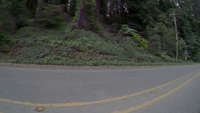
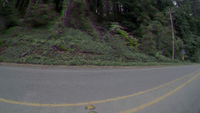
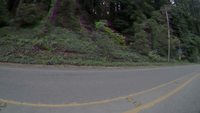
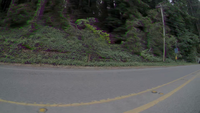
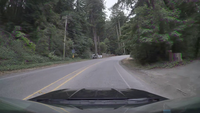
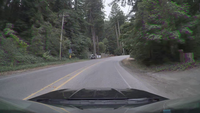
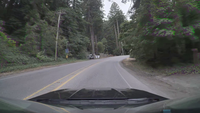
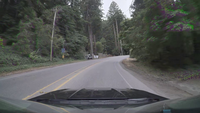
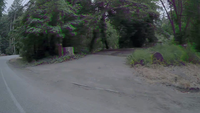
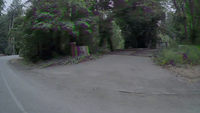
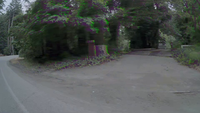
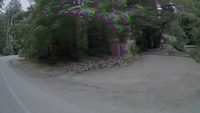
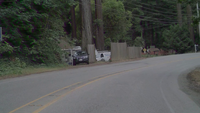
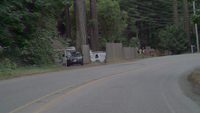
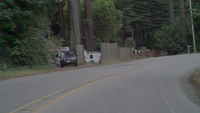
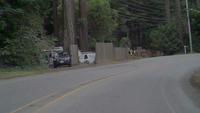

In [6]:
mp.show_images(data["image_frames"].flatten(0, 1).permute(0, 2, 3, 1), columns=4, width=200)

(-21.09922323226929, 18.71873197555542, -1.707053154706955, 55.64785870909691)

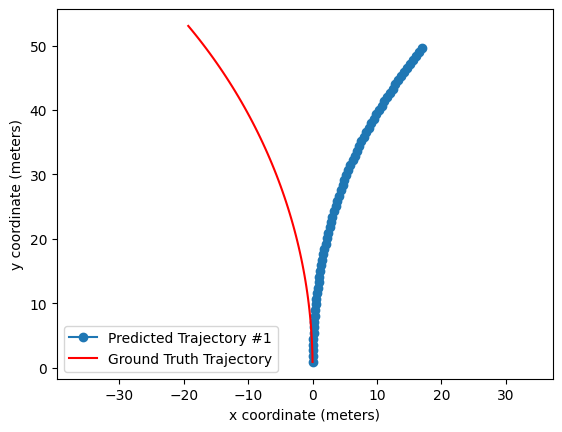

In [25]:
import matplotlib.pyplot as plt


def rotate_90cc(xy):
    # Rotate (x, y) by 90 deg CCW -> (y, -x)
    return np.stack([-xy[1], xy[0]], axis=0)


for i in range(pred_xyz.shape[2]):
    pred_xy = pred_xyz.cpu()[0, 0, i, :, :2].T.numpy()
    pred_xy_rot = rotate_90cc(pred_xy)
    gt_xy = data["ego_future_xyz"].cpu()[0, 0, :, :2].T.numpy()
    gt_xy_rot = rotate_90cc(gt_xy)
    plt.plot(*pred_xy_rot, "o-", label=f"Predicted Trajectory #{i + 1}")
plt.ylabel("y coordinate (meters)")
plt.xlabel("x coordinate (meters)")
plt.plot(*gt_xy_rot, "r-", label="Ground Truth Trajectory")
plt.legend(loc="best")
plt.axis("equal")

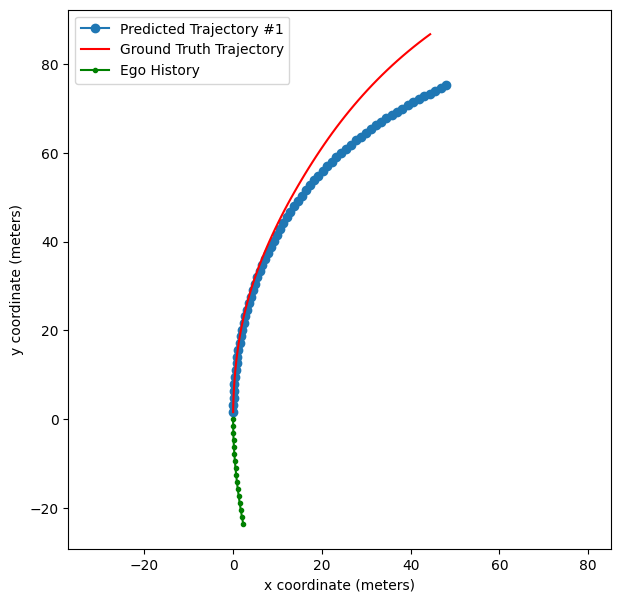

In [21]:
import matplotlib.pyplot as plt
import numpy as np


def rotate_90cc(xy):
    # Rotate (x, y) by 90 deg CCW
    return np.stack([-xy[1], xy[0]], axis=0)


plt.figure(figsize=(7, 7))

# 未来軌道（予測）
for i in range(pred_xyz.shape[2]):
    pred_xy = pred_xyz.cpu()[0, 0, i, :, :2].T.numpy()
    pred_xy_rot = rotate_90cc(pred_xy)
    plt.plot(*pred_xy_rot, "o-", label=f"Predicted Trajectory #{i + 1}")

# 未来軌道（GT）
gt_xy = data["ego_future_xyz"].cpu()[0, 0, :, :2].T.numpy()
gt_xy_rot = rotate_90cc(gt_xy)
plt.plot(*gt_xy_rot, "r-", label="Ground Truth Trajectory")

# 過去軌道
hist_xy = data["ego_history_xyz"].cpu()[0, 0, :, :2].T.numpy()
hist_xy_rot = rotate_90cc(hist_xy)
plt.plot(*hist_xy_rot, "g.-", label="Ego History")

plt.ylabel("y coordinate (meters)")
plt.xlabel("x coordinate (meters)")
plt.legend(loc="best")
plt.axis("equal")
plt.show()

In [8]:
pred_xy = pred_xyz.cpu().numpy()[0, 0, :, :, :2].transpose(0, 2, 1)
diff = np.linalg.norm(pred_xy - gt_xy[None, ...], axis=1).mean(-1)
print("minADE:", diff.min(), "meters")

minADE: 33.256874 meters


In [10]:
print(data["clip_id"])
print(data["ego_history_xyz"][0, 0, -1])

99a9ff74-d5cb-4f58-8364-bdd32e611c4f__physicsnemo_lowmu
tensor([0., 0., 0.])
